# 🔗 Notebook 04 — Luật kết hợp & Hệ thống Gợi ý Sản phẩm

**Mục tiêu:**
- **Luật kết hợp (Association Rules):** FP-Growth tìm cặp từ thường xuất hiện trong bình luận tiêu cực
- **Hệ thống Gợi ý:** Content-based filtering dựa trên TF-IDF Cosine Similarity
- Lưu rules và recommender để dùng trong API

**Đầu vào:** `datas/processed/reviews_with_clusters.csv`, `datas/recommend_dataset/`  
**Đầu ra:** `datas/models/association_rules.pkl`, `datas/models/recommender.pkl`

## 1. Import thư viện

In [61]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings
import sys
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns

# Luật kết hợp
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')
tqdm.pandas()

ROOT_DIR = Path('..').resolve()
PROCESSED_DIR = ROOT_DIR / 'datas' / 'processed'
MODELS_DIR = ROOT_DIR / 'datas' / 'models'
REC_DIR = ROOT_DIR / 'datas' / 'recommend_dataset'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT_DIR))
from src.data.catalog_builder import build_merged_catalog, load_prs_orders
from src.models.recommender import ProductRecommender
from src.models.collab_filter import CollaborativeFilteringRecommender

print('✅ Thư viện đã import thành công')

✅ Thư viện đã import thành công


## 2. Tải dữ liệu

In [62]:
df = pd.read_csv(PROCESSED_DIR / 'reviews_with_clusters.csv')
print(f'✅ Đã tải: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.head(3))

✅ Đã tải: (31469, 6)
Columns: ['review_text', 'processed_text', 'label', 'source', 'cluster', 'cluster_name']


,review_text,processed_text,label,source,cluster,cluster_name
0,Tốt Gói Hàng đẹp Shop phục vụ rất tốt.,gói hàng đẹp shop phục_vụ,1,tiki_sentiment,5,NaN
1,Mk nhận đk hàng rồi đẹp lắm cảm ơn shop nhé 😊.,đk hàng đẹp cảm_ơn shop,1,tiki_sentiment,7,NaN
2,Bố t thích áo này lắm y.,bố áo,1,tiki_sentiment,2,Đóng gói


## 3. Luật kết hợp — FP-Growth trên Bình luận Tiêu cực

In [63]:
# Lọc bình luận tiêu cực
df_negative = df[df['label'] == 0].copy()
print(f'Số bình luận tiêu cực: {len(df_negative):,}')

Số bình luận tiêu cực: 12,116


In [64]:
def text_to_transaction(text: str, min_word_len: int = 2) -> list:
    """Chuyển văn bản thành danh sách từ (transaction) cho FP-Growth."""
    if not isinstance(text, str):
        return []
    # Tách từ và loại trùng lặp (mỗi từ chỉ xuất hiện 1 lần trong 1 transaction)
    words = text.split()
    unique_words = list(dict.fromkeys(
        w for w in words if len(w) >= min_word_len
    ))
    return unique_words

# Xây dựng tập transactions
transactions = df_negative['processed_text'].apply(text_to_transaction).tolist()
transactions = [t for t in transactions if len(t) >= 2]  # Loại transaction rỗng

print(f'Số transactions hợp lệ: {len(transactions):,}')
print(f'Ví dụ transaction: {transactions[0]}')

Số transactions hợp lệ: 5,894
Ví dụ transaction: ['dây', 'nịt', 'ngực', 'suốt', 'rách']


In [65]:
# Mã hóa transactions thành one-hot matrix
print('🔄 Đang mã hóa transactions...')
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print(f'✅ Transaction matrix: {df_te.shape}')

🔄 Đang mã hóa transactions...
✅ Transaction matrix: (5894, 4950)


In [66]:
# Áp dụng FP-Growth (nhanh hơn Apriori ~10x)
print('🔄 Đang chạy FP-Growth...')
MIN_SUPPORT = 0.01  # Tối thiểu 1% transactions

frequent_itemsets = fpgrowth(
    df_te,
    min_support=MIN_SUPPORT,
    use_colnames=True
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'✅ Frequent itemsets: {len(frequent_itemsets):,}')
display(frequent_itemsets.sort_values('support', ascending=False).head(10))

🔄 Đang chạy FP-Growth...
✅ Frequent itemsets: 153


,support,itemsets,length
2,0.150492,frozenset({hàng}),1
4,0.147099,frozenset({áo}),1
3,0.143196,frozenset({giao}),1
10,0.140143,frozenset({shop}),1
16,0.129793,frozenset({sản_phẩm}),1
13,0.101629,frozenset({màu}),1
31,0.097387,frozenset({vải}),1
17,0.088225,frozenset({chất_lượng}),1
40,0.082457,frozenset({mua}),1
24,0.079403,frozenset({kém}),1


In [67]:
# Tạo luật kết hợp
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.2
)

# Lọc thêm theo confidence
rules = rules[rules['confidence'] >= 0.5].copy()
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

# Chuyển frozenset thành string để dễ xử lý
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'✅ Số luật kết hợp: {len(rules):,}')
print('\nTop 15 luật theo Lift:')
display(rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(15))

✅ Số luật kết hợp: 59

Top 15 luật theo Lift:


,antecedents_str,consequents_str,support,confidence,lift
0,"kém, shop",phục_vụ,0.013743,0.757009,31.870093
1,phục_vụ,"kém, shop",0.013743,0.578571,31.870093
2,đường,may,0.015439,0.614865,20.474653
3,may,đường,0.015439,0.514124,20.474653
4,"chất_lượng, tiền","kém, sản_phẩm",0.011367,0.736264,13.820186
5,thời_gian,"giao, hàng",0.018154,0.891667,12.603078
6,"sản_phẩm, tiền","chất_lượng, kém",0.011367,0.683673,12.475453
7,chậm,"giao, hàng",0.013912,0.811881,11.475366
8,"chất_lượng, sản_phẩm, tiền",kém,0.011367,0.858974,10.817938
9,"kém, tiền","chất_lượng, sản_phẩm",0.011367,0.697917,10.768379


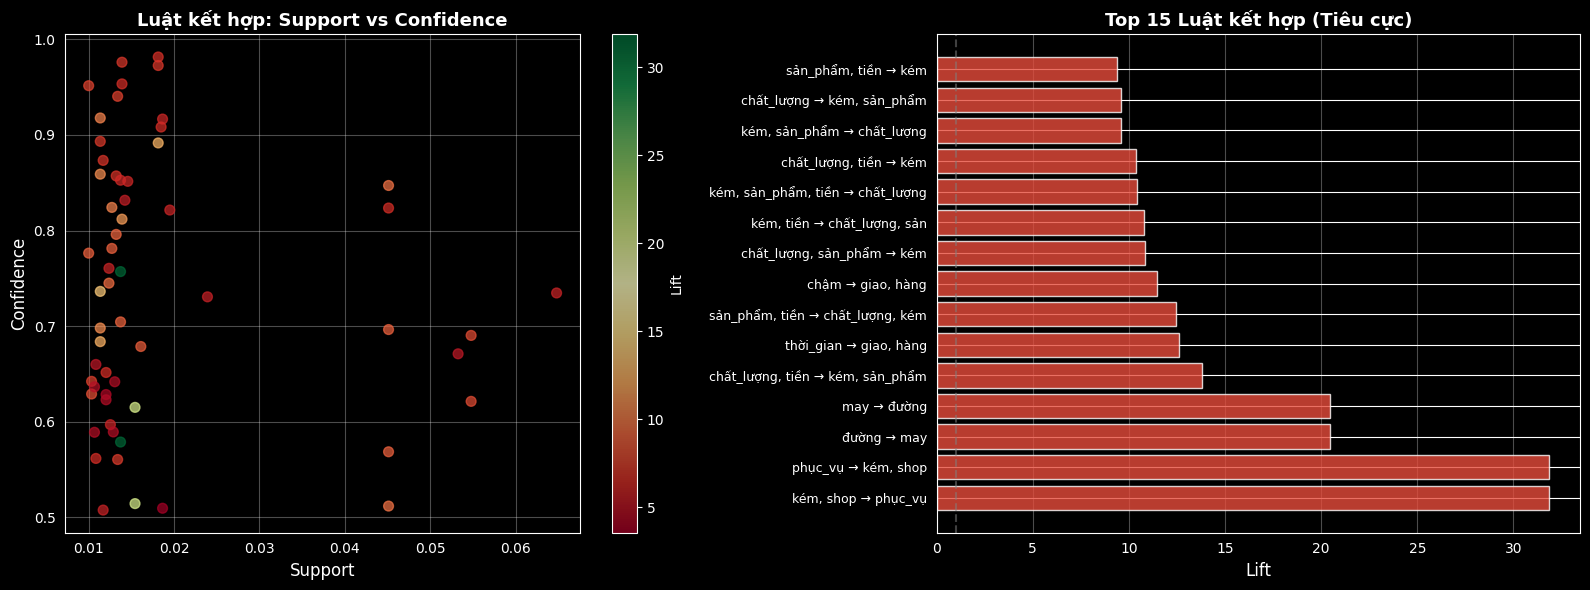

In [68]:
# Visualize top 20 luật — Heatmap Support × Confidence
top_rules = rules.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Support vs Confidence, màu = Lift
sc = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', alpha=0.7, s=50
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].set_title('Luật kết hợp: Support vs Confidence', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Bar chart top 15 theo lift
rule_labels = [f"{a} → {c}" for a, c in zip(
    top_rules['antecedents_str'].str[:20],
    top_rules['consequents_str'].str[:15]
)][:15]
axes[1].barh(range(len(rule_labels[:15])), top_rules['lift'][:15],
             color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(len(rule_labels[:15])))
axes[1].set_yticklabels(rule_labels[:15], fontsize=9)
axes[1].set_xlabel('Lift', fontsize=12)
axes[1].set_title('Top 15 Luật kết hợp (Tiêu cực)', fontsize=13, fontweight='bold')
axes[1].axvline(x=1, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'association_rules_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hệ thống Gợi ý Sản phẩm (Content-based)

In [69]:
# Duong dan catalog hien tai va dataset mau
CATALOG_PATH = MODELS_DIR / 'product_catalog.csv'
PRS_PRODUCTS_DIR = ROOT_DIR / 'samples' / 'product-recommendation-system' / 'datasets' / 'products_dataset'

print(f'Catalog path: {CATALOG_PATH}')
print(f'PRS products dir: {PRS_PRODUCTS_DIR} (exists={PRS_PRODUCTS_DIR.exists()})')

Catalog path: F:\codingSpace\Asm\ecom_rcm_1\datas\models\product_catalog.csv
PRS products dir: F:\codingSpace\Asm\ecom_rcm_1\samples\product-recommendation-system\datasets\products_dataset (exists=True)


In [70]:
# Hop nhat catalog hien tai + dataset mau (repo product-recommendation-system)
df_catalog = build_merged_catalog(
    existing_catalog_path=CATALOG_PATH if CATALOG_PATH.exists() else None,
    prs_products_dir=PRS_PRODUCTS_DIR if PRS_PRODUCTS_DIR.exists() else None,
    id_prefix='prs_',
    dedupe_subset=['name', 'category', 'price'],
)

print(f'✅ Product catalog: {df_catalog.shape}')
display(df_catalog[['product_id', 'name', 'category', 'price']].head(5))

✅ Product catalog: (18424, 11)


,product_id,name,category,price
0,0,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...,Khác,0.0
1,1,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ...",Khác,0.0
2,2,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...,Khác,0.0
3,3,Điện Thoại Siêu Dễ Thương Mini BM10 Thay Đổi G...,Khác,0.0
4,4,[Mã ELBAU1TR giảm 5% ] Điện thoại Samsung Gala...,Khác,0.0


In [71]:
# Dam bao combined_text day du cho vectorization
if 'combined_text' not in df_catalog.columns:
    df_catalog['combined_text'] = (
        df_catalog['name'].fillna('') + ' ' +
        df_catalog['category'].fillna('') + ' ' +
        df_catalog['description'].fillna('')
    ).str.strip()

missing_text = (df_catalog['combined_text'].str.len() == 0).sum()
print(f'✅ Missing combined_text: {missing_text}')
display(df_catalog.head(3))

✅ Missing combined_text: 0


,product_id,name,category,price,description,rating,image,solds,location,source,combined_text
0,0,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...,Khác,0.0,NaN,0.0,NaN,NaN,NaN,legacy,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...
1,1,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ...",Khác,0.0,NaN,0.0,NaN,NaN,NaN,legacy,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ..."
2,2,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...,Khác,0.0,NaN,0.0,NaN,NaN,NaN,legacy,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...


In [72]:
# Huấn luyện Recommender
recommender = ProductRecommender(ngram_range=(1, 2), max_features=30_000)
recommender.fit(df_catalog, text_column='combined_text')

print(f'✅ Recommender đã huấn luyện xong!')
print(f'   TF-IDF matrix: {recommender.tfidf_matrix.shape}')
print(f'   Số sản phẩm: {len(df_catalog):,}')

✅ Recommender đã huấn luyện xong!
   TF-IDF matrix: (18424, 30000)
   Số sản phẩm: 18,424


In [73]:
# Demo gợi ý
demo_queries = [
    'áo thun cotton thoáng mát',
    'điện thoại pin trâu camera đẹp',
    'kem dưỡng ẩm da mặt',
]

for query in demo_queries:
    print(f'\n🔍 Query: "{query}"')
    recs = recommender.recommend_by_query(query, top_k=5)
    if len(recs) > 0:
        display(recs)
    else:
        print('  Không tìm thấy sản phẩm phù hợp')


🔍 Query: "áo thun cotton thoáng mát"


,product_id,name,category,price,rating,similarity_score
16176,prs_15477,Áo Phông The Bad God Baseman - Áo Thun Chất Li...,áo thun,79.0,NaN,0.4674
14513,prs_13536,Áo Thun Acmedevi Form Rộng Thời Trang Nam Nữ C...,áo phông nữ,79.0,4.8,0.3920
14347,prs_13314,ÁO THUN DAINTY Unisex Áo phông nam nữ tay lỡ o...,áo phông nam,99.0,4.8,0.3890
13580,prs_12449,"Áo thun ba lỗ nam, tanktop 006Tk.IN, chuẩn gym...",áo ba lỗ,12.5,NaN,0.3742
13586,prs_12455,Áo thun ba lỗ nam tanktop 98 chuẩn gym mặc nhà...,áo ba lỗ,15.0,NaN,0.3487



🔍 Query: "điện thoại pin trâu camera đẹp"


,product_id,name,category,price,rating,similarity_score
935,968,Điện Thoại Pin Khủng Land Rover A8+,Khác,0.0,0.0,0.3513
1224,1265,Điện thoại Nokia 1280 chính hãng – CHUẦN - PIN...,Khác,0.0,0.0,0.3278
16201,prs_15502,điện thoại Vivo Y50 (8GB-128GB) -Pin trâu 5000...,điện thoại,1219000.0,NaN,0.3197
1640,1694,"Điện thoại Xiaomi Redmi 6 Pro, 2 sim pin trâu",Khác,0.0,0.0,0.3168
16179,prs_15480,Điện Thoại Thông Minh CHính Hãng Oppo A3s đã q...,điện thoại,520000.0,NaN,0.2957



🔍 Query: "kem dưỡng ẩm da mặt"


,product_id,name,category,price,rating,similarity_score
10353,prs_8819,Hộp Chống Ẩm Cho Máy Ảnh 10L + Hạt Hút Ẩm + Ẩm...,máy ảnh,62000.0,NaN,0.2054
17789,prs_17325,"Trà Dưỡng Sinh Túi Lọc 9 Vị, Bách Thông Dưỡng ...",đường,191425.0,NaN,0.1807
6596,prs_4438,𝐆𝐢𝐚̀𝐲 𝐓𝐡𝐞̂̉ 𝐓𝐡𝐚𝐨_𝐀𝐝𝐢𝐝𝐚𝐬 𝐒𝐚𝐦𝐛𝐚 Xám Kem ‘𝐋𝐢𝐧𝐞𝐧 𝐒...,giày nam,179000.0,NaN,0.1741
10416,prs_8882,"Hộp Chống Ẩm Cho Máy Ảnh, Ống Kính Nhỏ Gọn Tiệ...",máy ảnh,45000.0,NaN,0.1681
9059,prs_7343,Muối hầm thực dưỡng Sahu Sa Huỳnh Quảng Ngãi (...,muối,69.0,NaN,0.1539


In [74]:
# --- Collaborative Filtering (User-User) ---
ORDERS_PATH = ROOT_DIR / 'samples' / 'product-recommendation-system' / 'datasets' / 'orders_dataset' / 'order_data.csv'

if ORDERS_PATH.exists():
    df_orders = load_prs_orders(ORDERS_PATH, id_prefix='prs_')
    print(f'✅ Orders: {df_orders.shape}')
    print(f'Columns: {df_orders.columns.tolist()}')

    cf_recommender = CollaborativeFilteringRecommender(min_rating=0.0)
    cf_recommender.fit(
        df_orders, user_col='user_id', item_col='product_id', rating_col='rating'
    )

    print('✅ CF model đã huấn luyện xong!')
    print(f'   User-Item matrix: {cf_recommender.user_item_matrix.shape}')

    demo_user = df_orders['user_id'].iloc[0]
    demo_ids = cf_recommender.recommend_for_user(demo_user, top_k=5)
    print(f'🔎 Demo user: {demo_user} -> {demo_ids}')

    if demo_ids and not df_catalog.empty:
        display(df_catalog[df_catalog['product_id'].isin(demo_ids)].head(5))
else:
    print('⚠️ Không tìm thấy order_data.csv để train Collaborative Filtering')

✅ Orders: (500, 8)
Columns: ['order_id', 'user_id', 'product_id', 'product_name', 'price', 'rating', 'order_date', 'image']
✅ CF model đã huấn luyện xong!
   User-Item matrix: (99, 484)
🔎 Demo user: prs_18 -> []


## 5. Lưu kết quả

In [75]:
# Lưu association rules
rules_export = rules[['antecedents_str', 'consequents_str',
                       'support', 'confidence', 'lift']].copy()
rules_export.to_csv(MODELS_DIR / 'association_rules.csv',
                    index=False, encoding='utf-8-sig')
joblib.dump(rules_export, MODELS_DIR / 'association_rules.pkl')

# Lưu Recommender
joblib.dump(recommender, MODELS_DIR / 'recommender.pkl')

# Lưu catalog chuẩn hóa
df_catalog.to_csv(MODELS_DIR / 'product_catalog.csv',
                  index=False, encoding='utf-8-sig')

# Lưu Collaborative Filtering model (neu co)
if 'cf_recommender' in globals():
    joblib.dump(cf_recommender, MODELS_DIR / 'cf_recommender.pkl')

print('✅ Phase 4 hoàn thành! Các file đã lưu:')
print('  - datas/models/association_rules.pkl / .csv')
print('  - datas/models/recommender.pkl')
print('  - datas/models/product_catalog.csv')
print('  - datas/models/cf_recommender.pkl')

✅ Phase 4 hoàn thành! Các file đã lưu:
  - datas/models/association_rules.pkl / .csv
  - datas/models/recommender.pkl
  - datas/models/product_catalog.csv
  - datas/models/cf_recommender.pkl
